In [ ]:
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.7 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 1. Configuration
MAX_FEATURES = 10000  # Only consider the top 10k words
MAX_LEN = 200         # Cut off reviews after 200 words

print("Loading data...")
# Load data already split into train and test sets
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)

print(f"Training sequences: {len(x_train)}")
print(f"Test sequences: {len(x_test)}")

# 2. Padding Sequences
# Ensure all sequences are exactly MAX_LEN long
x_train = pad_sequences(x_train, maxlen=MAX_LEN)
x_test = pad_sequences(x_test, maxlen=MAX_LEN)

print(f"Shape of data after padding: {x_train.shape}")

Loading data...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training sequences: 25000
Test sequences: 25000
Shape of data after padding: (25000, 200)


In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

def build_model(hp):
    model = Sequential()

    # Layer 1: Embedding
    # Turns integers (word indices) into dense vectors of fixed size.
    # We tune the output_dim between 32 and 128.
    model.add(Embedding(input_dim=MAX_FEATURES,
                        output_dim=hp.Int('embedding_dim', min_value=32, max_value=128, step=32),
                        input_length=MAX_LEN))

    # Layer 2: LSTM
    # We tune the number of units (neurons) in the LSTM layer.
    model.add(LSTM(units=hp.Int('lstm_units', min_value=32, max_value=128, step=32)))

    # Layer 3: Dropout
    # Randomly sets input units to 0 to prevent overfitting.
    model.add(Dropout(rate=hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))

    # Layer 4: Dense (Output)
    # Single neuron with sigmoid activation for binary classification (0 or 1).
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    # We also tune the learning rate for the Adam optimizer.
    model.compile(optimizer=tf.keras.optimizers.Adam(
                    learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

def build_model(hp):
    model = Sequential()

    # Layer 1: Embedding
    # Turns integers (word indices) into dense vectors of fixed size.
    # We tune the output_dim between 32 and 128.
    model.add(Embedding(input_dim=MAX_FEATURES,
                        output_dim=hp.Int('embedding_dim', min_value=32, max_value=128, step=32),
                        input_length=MAX_LEN))

    # Layer 2: LSTM
    # We tune the number of units (neurons) in the LSTM layer.
    model.add(LSTM(units=hp.Int('lstm_units', min_value=32, max_value=128, step=32)))

    # Layer 3: Dropout
    # Randomly sets input units to 0 to prevent overfitting.
    model.add(Dropout(rate=hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))

    # Layer 4: Dense (Output)
    # Single neuron with sigmoid activation for binary classification (0 or 1).
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    # We also tune the learning rate for the Adam optimizer.
    model.compile(optimizer=tf.keras.optimizers.Adam(
                    learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy', # We want to maximize validation accuracy
    max_trials=5,             # Total number of different model configurations to test
    executions_per_trial=1,   # Run each configuration once
    directory='my_dir',       # Directory to save logs
    project_name='imdb_lstm_tuning'
)

# Display a summary of the search space
tuner.search_space_summary()

# Start the search
# We use a subset of epochs (e.g., 3) just to find the best params quickly
print("\nStarting Hyperparameter Search...")
tuner.search(x_train, y_train,
             epochs=3,
             validation_split=0.2,
             batch_size=64)

Trial 5 Complete [00h 00m 15s]
val_accuracy: 0.8697999715805054

Best val_accuracy So Far: 0.8762000203132629
Total elapsed time: 00h 01m 16s


In [ ]:
# Get the best hyperparameters found
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete.
Best Embedding Dim: {best_hps.get('embedding_dim')}
Best LSTM Units: {best_hps.get('lstm_units')}
Best Dropout Rate: {best_hps.get('dropout_rate')}
Best Learning Rate: {best_hps.get('learning_rate')}
""")

# Build the model with the best hyperparameters
model = tuner.hypermodel.build(best_hps)

# Train the best model fully
history = model.fit(x_train, y_train,
                    epochs=7, # Train for longer now
                    validation_split=0.2,
                    batch_size=64)


The hyperparameter search is complete.
Best Embedding Dim: 32
Best LSTM Units: 64
Best Dropout Rate: 0.30000000000000004
Best Learning Rate: 0.001

Epoch 1/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6645 - loss: 0.5873 - val_accuracy: 0.8596 - val_loss: 0.3382
Epoch 2/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8838 - loss: 0.2983 - val_accuracy: 0.8524 - val_loss: 0.3668
Epoch 3/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9229 - loss: 0.2139 - val_accuracy: 0.8550 - val_loss: 0.3447
Epoch 4/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9415 - loss: 0.1592 - val_accuracy: 0.8732 - val_loss: 0.3476
Epoch 5/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9583 - loss: 0.1304 - val_accuracy: 0.8680 - val_loss: 0.3696
Epoch 6/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9674 - loss: 0.0957 - val_accuracy: 0.8664 - val_loss: 0.4029
Epoch 7/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9780 - loss: 0.07

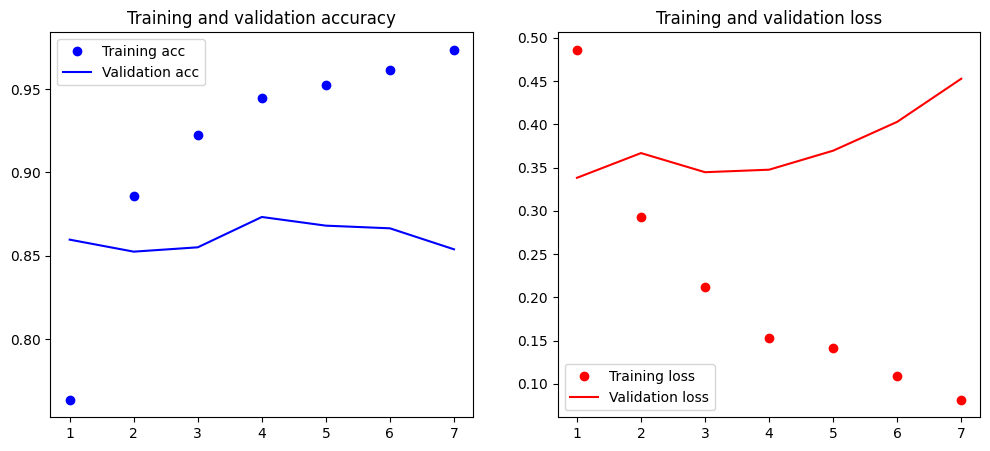


Evaluating on Test Data...
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8458 - loss: 0.4842
Test Accuracy: 84.61%


In [ ]:
import matplotlib.pyplot as plt

# 1. Plot Accuracy and Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

# 2. Final Evaluation on Test Data
print("\nEvaluating on Test Data...")
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

In [ ]:
# Get the word index from the dataset
word_index = imdb.get_word_index()

def predict_sentiment(text):
    # Tokenize and pad the input text
    tokens = [word_index.get(word, 0) for word in text.lower().split()]
    padded_tokens = pad_sequences([tokens], maxlen=MAX_LEN)

    # Predict
    prediction = model.predict(padded_tokens)[0][0]

    print(f"Text: '{text}'")
    print(f"Score: {prediction:.4f}")
    if prediction > 0.5:
        print("Sentiment: POSITIVE \n")
    else:
        print("Sentiment: NEGATIVE \n")

# Test custom sentences
predict_sentiment("This movie was absolutely fantastic and thrilling")
predict_sentiment("I hated every moment of it, terrible acting")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Text: 'This movie was absolutely fantastic and thrilling'
Score: 0.1603
Sentiment: NEGATIVE 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Text: 'I hated every moment of it, terrible acting'
Score: 0.6666
Sentiment: POSITIVE 



782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step


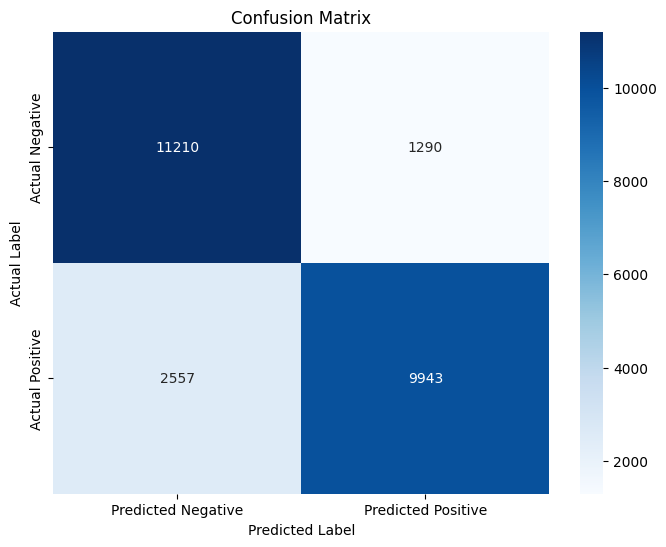

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions (returns probabilities between 0 and 1)
y_pred_probs = model.predict(x_test)

# 2. Convert probabilities to binary class (0 or 1) based on 0.5 threshold
y_pred = (y_pred_probs > 0.5).astype("int32")

# 3. Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

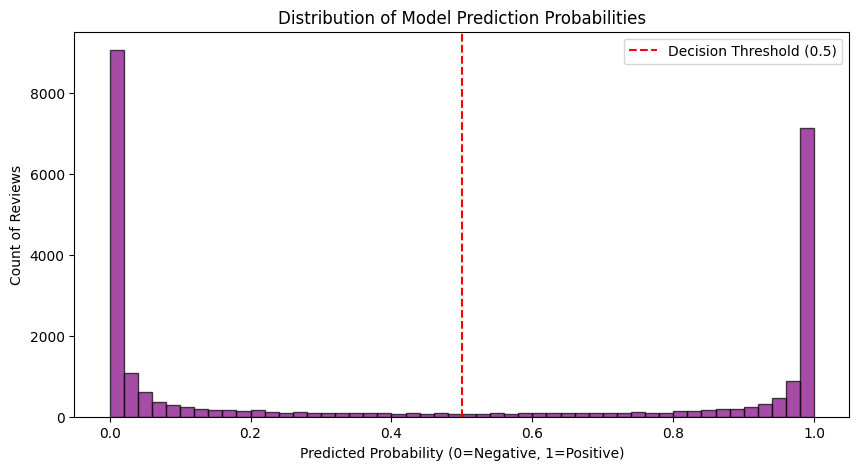

In [ ]:
plt.figure(figsize=(10, 5))

# Plot histogram of predicted probabilities
plt.hist(y_pred_probs, bins=50, alpha=0.7, color='purple', edgecolor='black')

plt.title('Distribution of Model Prediction Probabilities')
plt.xlabel('Predicted Probability (0=Negative, 1=Positive)')
plt.ylabel('Count of Reviews')
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.legend()
plt.show()